In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
data = pd.read_csv("2) loan approval data.csv")

In [3]:
data.head()
data.describe()
data.isnull().sum()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [4]:
# handle missing values using imputer
from sklearn.impute import SimpleImputer
num_imp = SimpleImputer(strategy="mean")
cat_imp = SimpleImputer(strategy = "most_frequent")

In [5]:
numerical_columns = data.select_dtypes(include = ["number"]).columns
catagorical_columns = data.select_dtypes(include = ["object"]).columns

In [6]:
data[numerical_columns] = num_imp.fit_transform(data[numerical_columns])
data[catagorical_columns] = cat_imp.fit_transform(data[catagorical_columns])

In [7]:
data.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

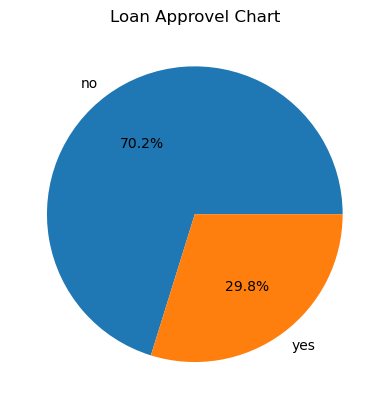

In [8]:
# performing exploratory data analylis EDA
classes_count = data["Loan_Approved"].value_counts()
plt.pie(classes_count , labels=["no" , "yes"] , autopct="%1.1f%%")
plt.title("Loan Approvel Chart")
plt.show()

<Axes: xlabel='Applicant_Income', ylabel='Count'>

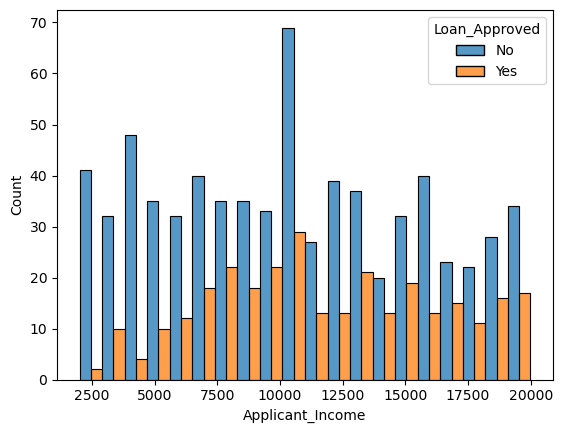

In [9]:
# Analylises the other catagaries

sns.histplot(
    data = data,
    x = "Applicant_Income",
    hue = "Loan_Approved",
    multiple = "dodge",
    bins=20
)

<Axes: xlabel='Credit_Score', ylabel='Applicant_Income'>

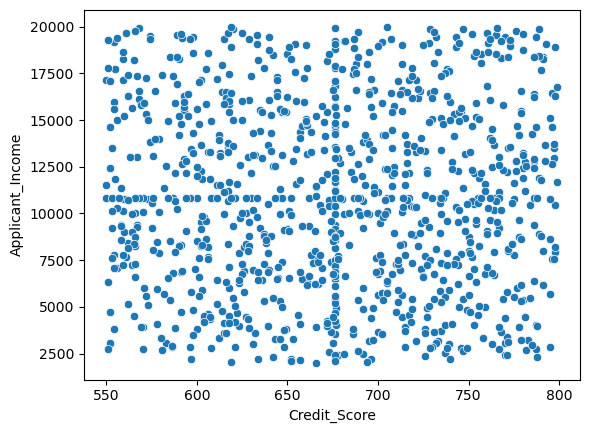

In [10]:
sns.scatterplot(
    data = data,
    x= "Credit_Score",
    y = "Applicant_Income"
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

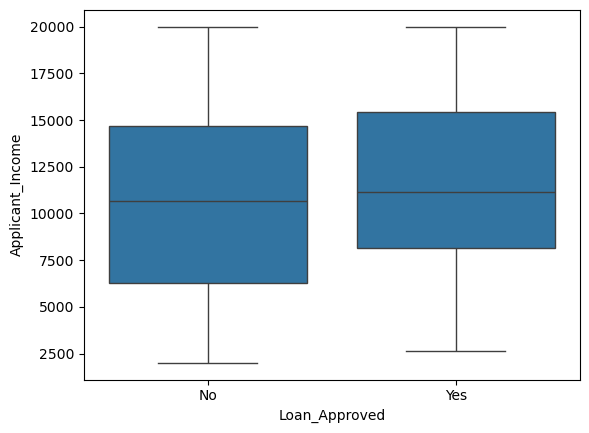

In [11]:
sns.boxplot(
    data = data,
    x= "Loan_Approved", 
    y = "Applicant_Income"
)

In [12]:
# ENCOADING
from sklearn.preprocessing import LabelEncoder , OneHotEncoder
le = LabelEncoder()
data["Employment_Status"] = le.fit_transform(data["Employment_Status"])
data["Loan_Approved"] = le.fit_transform(data["Loan_Approved"])
data["Property_Area"] = le.fit_transform(data["Property_Area"])
data["Marital_Status"] = le.fit_transform(data["Marital_Status"])
data["Education_Level"] = le.fit_transform(data["Education_Level"])

In [13]:
coln = ['Employer_Category','Gender','Loan_Purpose']
ohe = OneHotEncoder(drop = "first" , sparse_output = False , handle_unknown='ignore' )
encoded = ohe.fit_transform(data[coln])
encoded = pd.DataFrame(encoded , columns = ohe.get_feature_names_out(coln) , index = data.index)
data = pd.concat([data.drop(columns = coln) , encoded] , axis = 1)

<Axes: >

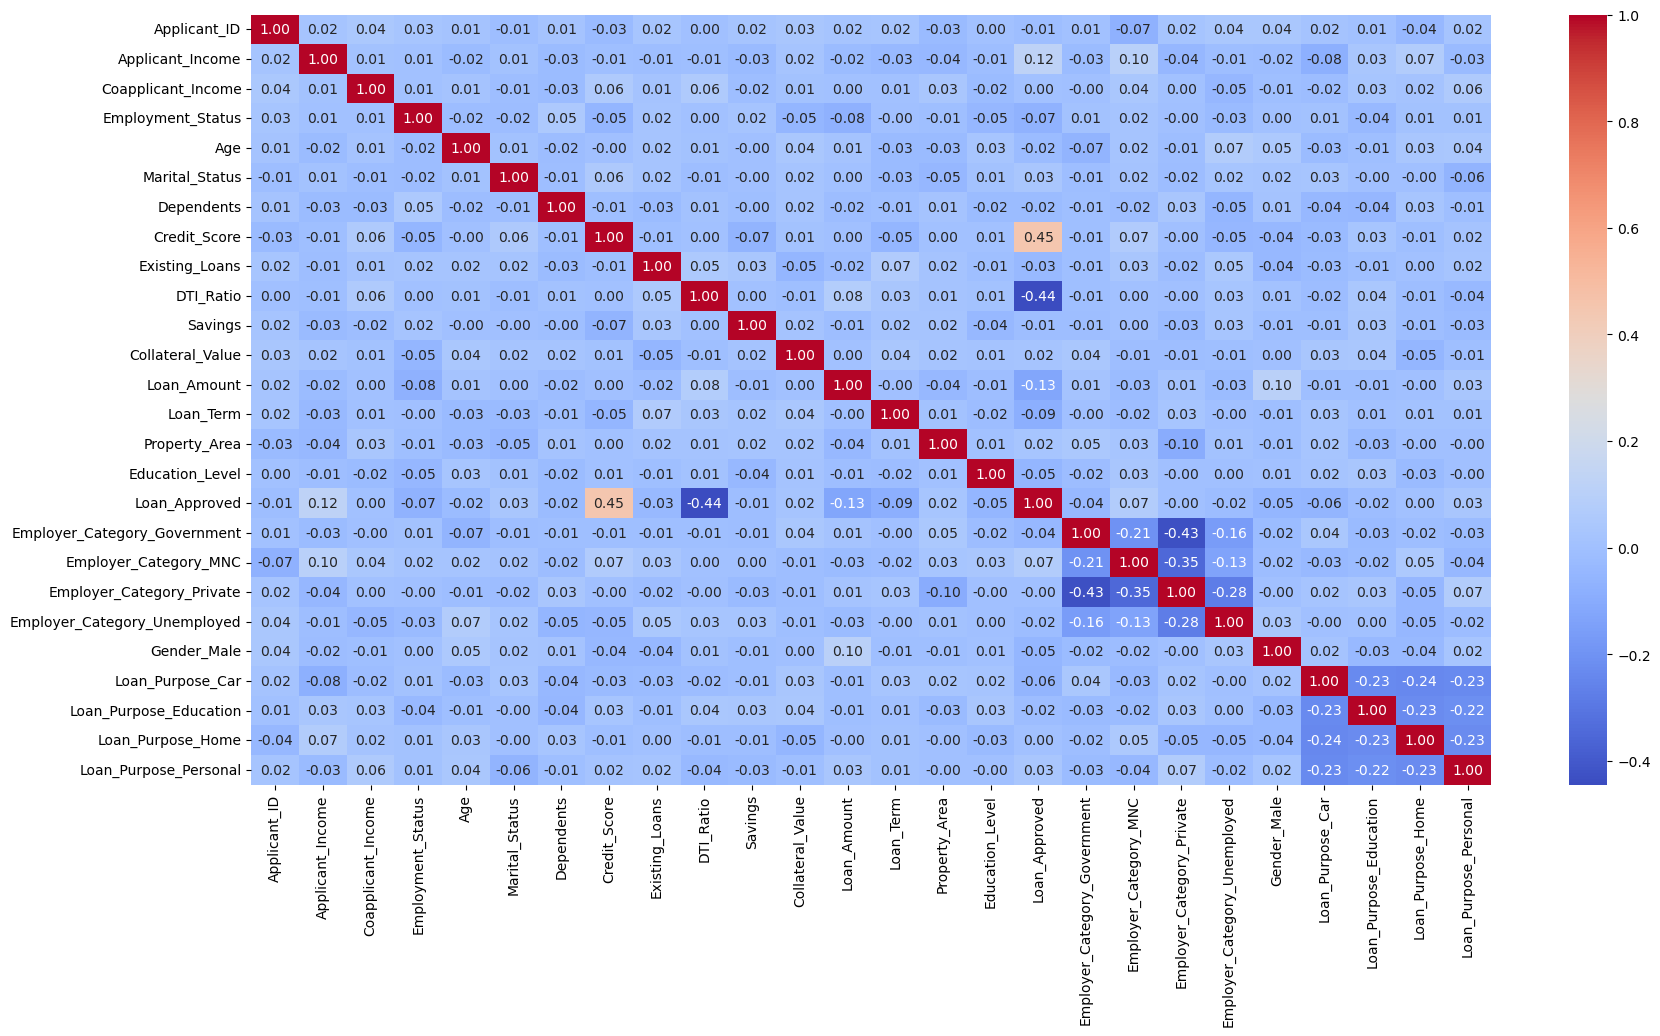

In [14]:
# CORRELATION HEATMAP
num_coln = data.select_dtypes("number")
corr_matrix = num_coln.corr()
plt.figure(figsize=(20,10))
sns.heatmap(
    corr_matrix,
    annot = True,
    fmt = ".2f",
    cmap = "coolwarm"
)

In [15]:
# Train-Test_split & Feature Engineering

X = data.drop(columns = ["Loan_Approved"])
y = data["Loan_Approved"]

X_train , X_test , y_train , y_test = train_test_split(
    X , y , test_size = 0.2 , random_state=42
)
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Applicant_ID                  1000 non-null   float64
 1   Applicant_Income              1000 non-null   float64
 2   Coapplicant_Income            1000 non-null   float64
 3   Employment_Status             1000 non-null   int64  
 4   Age                           1000 non-null   float64
 5   Marital_Status                1000 non-null   int64  
 6   Dependents                    1000 non-null   float64
 7   Credit_Score                  1000 non-null   float64
 8   Existing_Loans                1000 non-null   float64
 9   DTI_Ratio                     1000 non-null   float64
 10  Savings                       1000 non-null   float64
 11  Collateral_Value              1000 non-null   float64
 12  Loan_Amount                   1000 non-null   float64
 13  Loan

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [25]:
#  Train models & evaluation

# Logestic regression
from sklearn.metrics import confusion_matrix , precision_score , accuracy_score , recall_score , f1_score
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(X_train_scaled , y_train)

y_pred = log_model.predict(X_test_scaled)

# evaluation
print("precision_score score = " , precision_score(y_pred , y_test))
print("recall_score score = " , recall_score(y_pred , y_test))
print("f1_score score = " , f1_score(y_pred , y_test))
print("\nAccuracy score = " , accuracy_score(y_pred , y_test))
print("confusion_matrix score = " , confusion_matrix(y_pred , y_test))

precision_score score =  0.7377049180327869
recall_score score =  0.8333333333333334
f1_score score =  0.782608695652174

Accuracy score =  0.875
confusion_matrix score =  [[130  16]
 [  9  45]]


In [38]:
# KNN
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors = 5)
knn_model.fit(X_train_scaled , y_train)

y_pred = knn_model.predict(X_test_scaled)

# evaluation
print("precision_score score = " , precision_score(y_pred , y_test))
print("recall_score score = " , recall_score(y_pred , y_test))
print("f1_score score = " , f1_score(y_pred , y_test))
print("\nAccuracy score = " , accuracy_score(y_pred , y_test))
print("confusion_matrix score = " , confusion_matrix(y_pred , y_test))

precision_score score =  0.4426229508196721
recall_score score =  0.627906976744186
f1_score score =  0.5192307692307693

Accuracy score =  0.75
confusion_matrix score =  [[123  34]
 [ 16  27]]


In [39]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_scaled , y_train)

y_pred = nb_model.predict(X_test_scaled)

# evaluation
print("precision_score score = " , precision_score(y_pred , y_test))
print("recall_score score = " , recall_score(y_pred , y_test))
print("f1_score score = " , f1_score(y_pred , y_test))
print("\nAccuracy score = " , accuracy_score(y_pred , y_test))
print("confusion_matrix score = " , confusion_matrix(y_pred , y_test))

precision_score score =  0.7377049180327869
recall_score score =  0.8035714285714286
f1_score score =  0.7692307692307693

Accuracy score =  0.865
confusion_matrix score =  [[128  16]
 [ 11  45]]
